In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

In [3]:
os.chdir("/accounts/projects/jchayes/commnotes/analysis")

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
import statsmodels.formula.api as smf
import statsmodels.api as sm


from src.data_loader import *
from src.analysis import *
from src.visualization import *
from src.utils import *

In [5]:
# --- Configuration (Corrected Paths) ---
# Using the absolute paths from your working environment
NOTES_PATH = "/scratch/users/commnotes/communitynotes/sourcecode/notes-00000.tsv"
HISTORY_PATH = "/scratch/users/commnotes/communitynotes/sourcecode/noteStatusHistory-00000.tsv"
RATINGS_DIR = "/scratch/users/commnotes/communitynotes/sourcecode/ratings"
PAPER_DATA_URL = "https://raw.githubusercontent.com/trenault/CommunityNotes/main/database_replication.csv"
WEEKLY_OUTPUTS_PATH = "/scratch/users/commnotes/communitynotes2022/communitynotes/static/sourcecode/weekly_outputs"

WEEKLY_OUTPUTS_PATH_2025 = "/scratch/users/commnotes/communitynotes/sourcecode/weekly_outputs"


max_date = "2023-06-01"

In [6]:
print("--- Loading and Preparing Data ---")
# This DataFrame contains data related to "notes" associated with tweets. It includes unique IDs for notes, authors, and tweets, along with
# timestamps, classifications (e.g., "MISINFORMED_OR_POTENTIALLY_MISLEADING"), and other
# attributes describing the history of the notes
notes_df = pd.read_csv(NOTES_PATH, sep='\\t', dtype={'noteAuthorParticipantId': str, 'tweetId': str, 'noteId': str})
notes_df["noteId"]=notes_df["noteId"].astype(int)

# The following is all note ratings published by X
# I only kept the following columns "'noteId', 'raterParticipantId', 'createdAtMillis', 'helpfulnessLevel'" since we don't use the rest.
ratings_df = read_ratings_from_directory(RATINGS_DIR, start_date_str="2022-06-01",end_date_str=max_date)

# The following df is the results of the matrix factorzation 
note_df_full, rater_df, status_df, helpfulness_df, aux_df = load_weekly_outputs(WEEKLY_OUTPUTS_PATH,debug=False)

history_df =   pd.read_csv(HISTORY_PATH, sep='\\t', dtype={'noteAuthorParticipantId': str, 'tweetId': str, 'noteId': str})
paper_df = pd.read_csv(PAPER_DATA_URL, dtype={'tweet_id': str})

# The following df is notes with corresponding topics. Topics are modelled by the X topic modeling algorithm.
notes_df_topic = pd.read_csv("/accounts/projects/jchayes/commnotes/df_notes_with_topics.csv")


notes_df_topic['noteId'] = notes_df_topic['noteId'].astype(int)

--- Loading and Preparing Data ---


/tmp/ipykernel_2579960/2332541645.py:5: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


Found 16 total rating files. Processing them in chunks to filter by date.


Loading weekly outputs: 100%|██████████| 84/84 [01:59<00:00,  1.42s/it]


note is loaded.
rater is loaded.
status is loaded.
helpfulness is loaded.
aux is loaded.


/tmp/ipykernel_2579960/2332541645.py:15: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


In [7]:
ratings_df['createdAtDate'] = pd.to_datetime(ratings_df['createdAtMillis'], unit='ms')

In [8]:
note_df_full_2025, rater_df_2025, status_df_2025, helpfulness_df_2025, aux_df_2025 = load_weekly_outputs(WEEKLY_OUTPUTS_PATH_2025,debug=False)

Loading weekly outputs: 100%|██████████| 44/44 [00:03<00:00, 11.15it/s]

note is loaded.
rater is loaded.
status is loaded.
key without data status
helpfulness is loaded.
key without data helpfulness
aux is loaded.
key without data aux


In [9]:
rater_df_2025 = rater_df_2025.rename(columns={"internalRaterFactor1": "raterFactor1", "internalRaterIntercept": "raterIntercept"})
note_df_full_2025 = note_df_full_2025.rename(columns={"internalNoteFactor1": "noteFactor1", "internalNoteIntercept": "noteIntercept"})

In [10]:
rollout_date = pd.to_datetime("2022-10-01")

In [11]:
# get one cohort of legacy raters who were active before rollout date
legacy_users = ratings_df[ratings_df['createdAtDate'] < rollout_date]['raterParticipantId'].unique()

# get one cohort of new raters who joined between Oct. 2022 and Jan. 2023
new_users = ratings_df[(ratings_df['createdAtDate'] >= rollout_date) & (ratings_df['createdAtDate'] < pd.to_datetime("2023-01-01"))]['raterParticipantId'].unique()
new_users = [user for user in new_users if user not in legacy_users]

In [12]:
len(legacy_users), len(new_users)

(1202, 7177)

In [13]:
# Also read in LLM modelled-topics
notes_df_llms = pd.read_csv("/accounts/projects/jchayes/commnotes/notes_llm_topic.csv")

# Latent Factor Distribution Shift


--- Slide 8 & 9: Factor Distribution Shifts ---


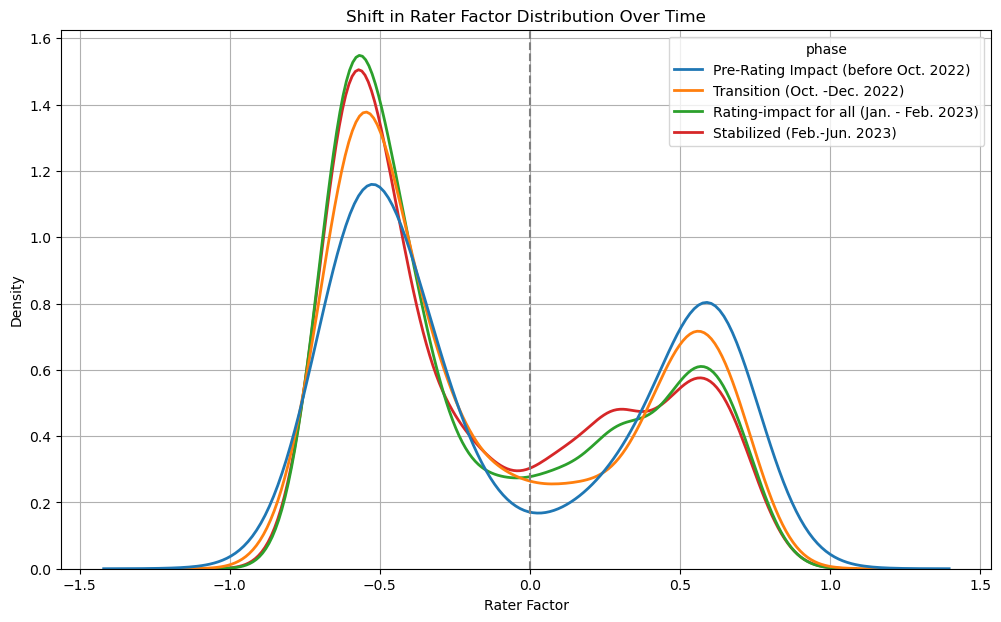

In [33]:
# Prepare common dataframes
latest_rater_factors = rater_df.sort_values('week_dt').drop_duplicates('raterParticipantId', keep='last')
latest_note_factors = note_df_full.sort_values('week_dt').drop_duplicates('noteId', keep='last')

# Slide 8 & 9: Factor Distribution Shifts
print("\n--- Slide 8 & 9: Factor Distribution Shifts ---")
rater_df['month_str'] = rater_df['week_dt'].dt.strftime('%Y-%m')
rater_df['phase'] = rater_df['month_str'].apply(assign_phase)

# Save the plot to final_code/figures
plot_factor_distribution_shifts(rater_df, 'raterFactor1', save_path='final_code/figures/rater_factor_distribution_shift_2022.png')


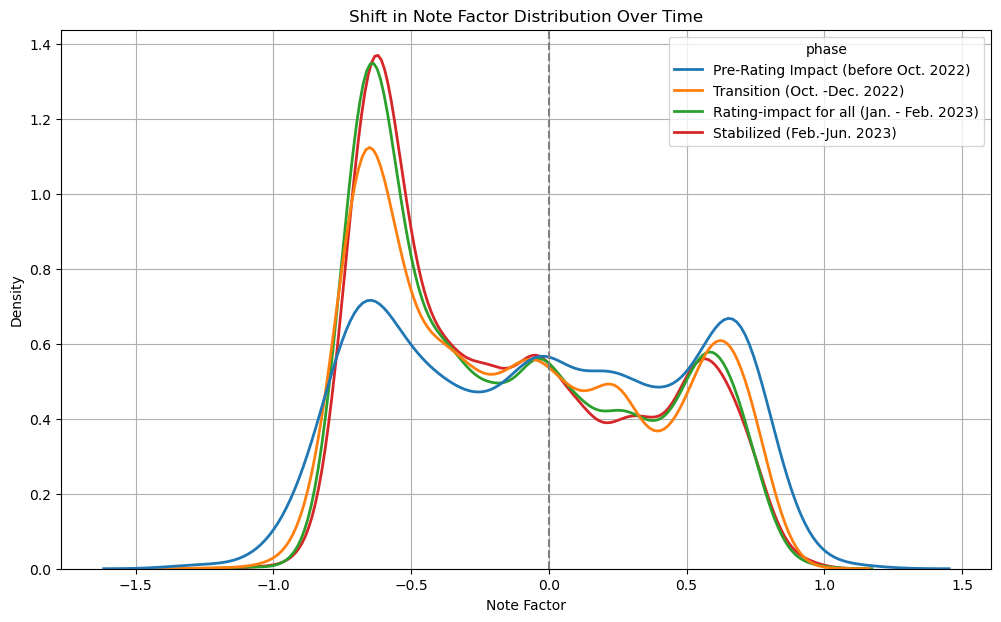

In [34]:
note_df_full['month_str'] = note_df_full['week_dt'].dt.strftime('%Y-%m')
note_df_full['phase'] = note_df_full['month_str'].apply(assign_phase)
plot_factor_distribution_shifts(note_df_full, 'noteFactor1', save_path='final_code/figures/note_factor_distribution_shift_2022.png')

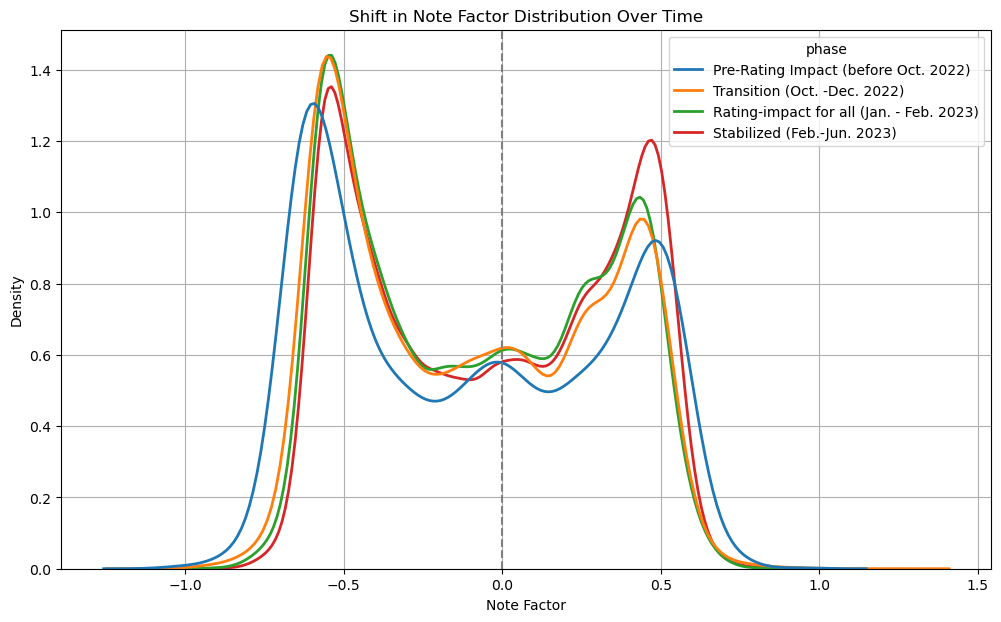

In [35]:
note_df_full_2025['month_str'] = note_df_full_2025['week_dt'].dt.strftime('%Y-%m')
note_df_full_2025['phase'] = note_df_full_2025['month_str'].apply(assign_phase)
plot_factor_distribution_shifts(note_df_full_2025, 'noteFactor1', save_path='final_code/figures/note_factor_distribution_shift_2025.png')


--- Slide 8 & 9: Factor Distribution Shifts ---


/tmp/ipykernel_658828/2204482564.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_658828/2204482564.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


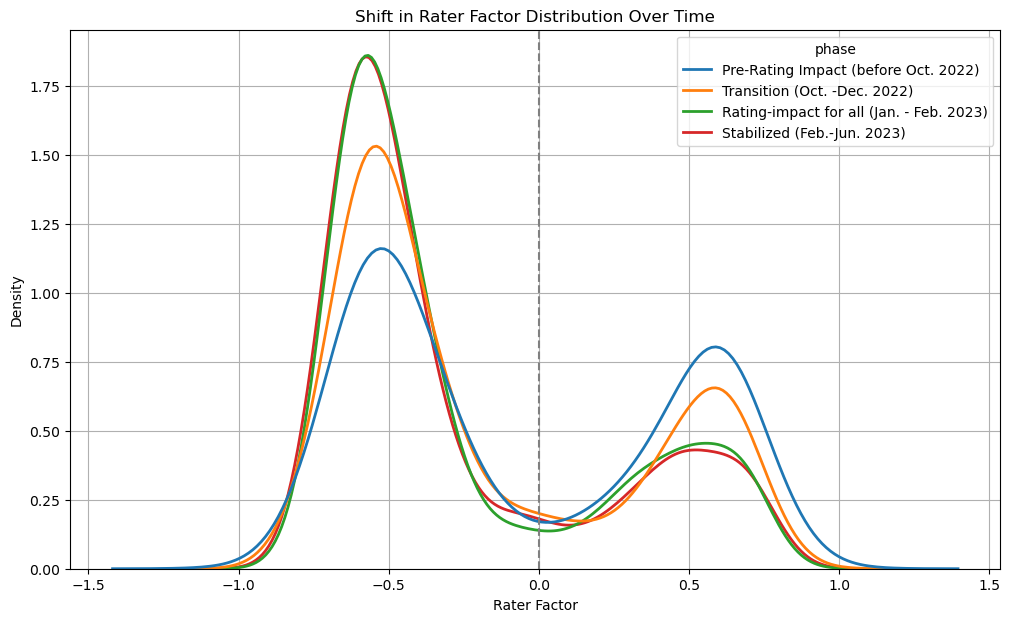

In [36]:
legacy_rater_df = rater_df[rater_df['raterParticipantId'].isin(legacy_users)]

# Prepare common dataframes
latest_rater_factors = legacy_rater_df.sort_values('week_dt').drop_duplicates('raterParticipantId', keep='last')
latest_note_factors = note_df_full.sort_values('week_dt').drop_duplicates('noteId', keep='last')

# Slide 8 & 9: Factor Distribution Shifts
print("\n--- Slide 8 & 9: Factor Distribution Shifts ---")
legacy_rater_df['month_str'] = legacy_rater_df['week_dt'].dt.strftime('%Y-%m')
legacy_rater_df['phase'] = legacy_rater_df['month_str'].apply(assign_phase)
plot_factor_distribution_shifts(legacy_rater_df, 'raterFactor1', save_path='final_code/figures/rater_factor_distribution_shift_2022_legacy.png')


--- Slide 8 & 9: Factor Distribution Shifts ---


/tmp/ipykernel_658828/1753072719.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_658828/1753072719.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


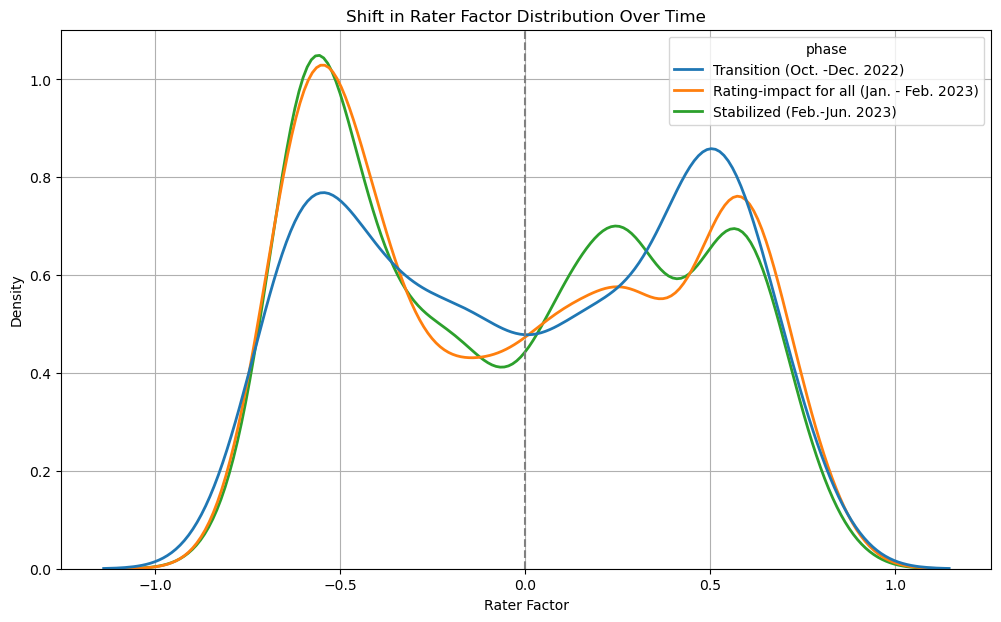

In [37]:
new_user_df = rater_df[rater_df['raterParticipantId'].isin(new_users)]

# Prepare common dataframes
latest_rater_factors = new_user_df.sort_values('week_dt').drop_duplicates('raterParticipantId', keep='last')
latest_note_factors = note_df_full.sort_values('week_dt').drop_duplicates('noteId', keep='last')

# Slide 8 & 9: Factor Distribution Shifts
print("\n--- Slide 8 & 9: Factor Distribution Shifts ---")
new_user_df['month_str'] = new_user_df['week_dt'].dt.strftime('%Y-%m')
new_user_df['phase'] = new_user_df['month_str'].apply(assign_phase)
plot_factor_distribution_shifts(new_user_df, 'raterFactor1', save_path='final_code/figures/rater_factor_distribution_shift_2022_new.png')


--- Slide 8 & 9: Factor Distribution Shifts ---


/tmp/ipykernel_658828/2608392019.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_658828/2608392019.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


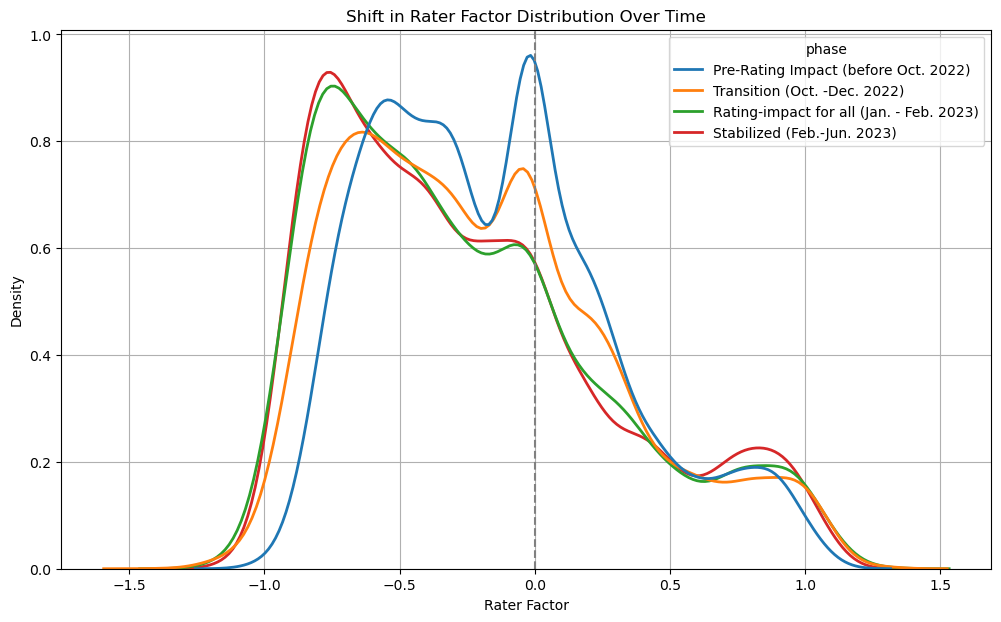

In [38]:
legacy_rater_df_2025 = rater_df_2025[rater_df_2025['raterParticipantId'].isin(legacy_users)]

# Prepare common dataframes
latest_rater_factors = legacy_rater_df_2025.sort_values('week_dt').drop_duplicates('raterParticipantId', keep='last')
# latest_note_factors = note_df_full_2025.sort_values('week_dt').drop_duplicates('noteId', keep='last')

# Slide 8 & 9: Factor Distribution Shifts
print("\n--- Slide 8 & 9: Factor Distribution Shifts ---")
legacy_rater_df_2025['month_str'] = legacy_rater_df_2025['week_dt'].dt.strftime('%Y-%m')
legacy_rater_df_2025['phase'] = legacy_rater_df_2025['month_str'].apply(assign_phase)
plot_factor_distribution_shifts(legacy_rater_df_2025, 'raterFactor1', save_path='final_code/figures/rater_factor_distribution_shift_2025_legacy.png')


--- Slide 8 & 9: Factor Distribution Shifts ---


/tmp/ipykernel_658828/3336956245.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_658828/3336956245.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


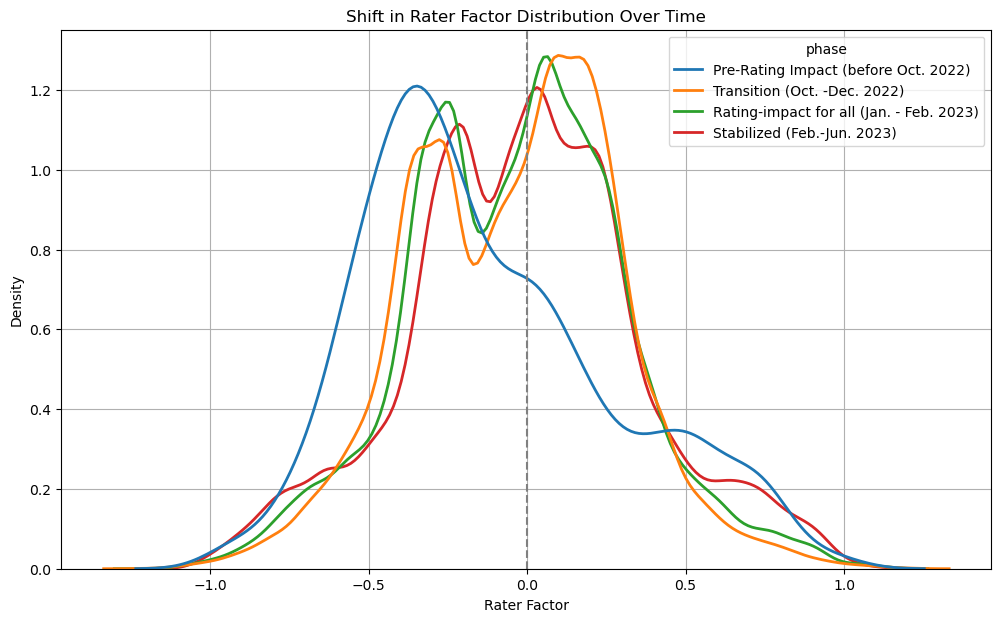

In [39]:
new_rater_df_2025 = rater_df_2025[rater_df_2025['raterParticipantId'].isin(new_users)]

# Prepare common dataframes
latest_rater_factors = new_rater_df_2025.sort_values('week_dt').drop_duplicates('raterParticipantId', keep='last')
# latest_note_factors = note_df_full_2025.sort_values('week_dt').drop_duplicates('noteId', keep='last')

# Slide 8 & 9: Factor Distribution Shifts
print("\n--- Slide 8 & 9: Factor Distribution Shifts ---")
new_rater_df_2025['month_str'] = new_rater_df_2025['week_dt'].dt.strftime('%Y-%m')
new_rater_df_2025['phase'] = new_rater_df_2025['month_str'].apply(assign_phase)
plot_factor_distribution_shifts(new_rater_df_2025, 'raterFactor1', save_path='final_code/figures/rater_factor_distribution_shift_2025_new.png')

In [15]:
# measure the difference in factor shift for legacy vs. new users between oct. 1, 2022 to jan. 1, 2023
def compute_factor_shift(df, user_list, factor_col):
    df = df.copy()
    df['week_dt'] = pd.to_datetime(df['week_dt'])

    # First factor after Oct 1, 2022
    first_df = (
        df[
            (df['raterParticipantId'].isin(user_list)) &
            (df['week_dt'] > pd.Timestamp('2022-10-01'))
        ]
        .sort_values('week_dt')
        .groupby('raterParticipantId', as_index=False)
        .first()
        [['raterParticipantId', factor_col]]
        .rename(columns={factor_col: 'first_factor'})
    )

    # First factor after Jan 1, 2023
    last_df = (
        df[
            (df['raterParticipantId'].isin(user_list)) &
            (df['week_dt'] > pd.Timestamp('2023-01-01'))
        ]
        .sort_values('week_dt')
        .groupby('raterParticipantId', as_index=False)
        .first()
        [['raterParticipantId', factor_col]]
        .rename(columns={factor_col: 'last_factor'})
    )

    # Merge and compute shift
    out = first_df.merge(last_df, on='raterParticipantId', how='inner')
    out['factor_shift'] = out['last_factor'] - out['first_factor']

    return out


In [16]:
legacy_shift_2022 = compute_factor_shift(rater_df, legacy_users, 'raterFactor1')
new_shift_2022 = compute_factor_shift(rater_df, new_users, 'raterFactor1')

In [17]:
legacy_shift_2025 = compute_factor_shift(rater_df_2025, legacy_users, 'raterFactor1')
new_shift_2025 = compute_factor_shift(rater_df_2025, new_users, 'raterFactor1')

In [18]:
len(legacy_shift_2025), len(new_shift_2025)

(1147, 4323)

In [19]:
# permutation test for whether legacy users and different factor shift than new users
def perm_test(x, y, n_perm=10_000, seed=0, stat=np.mean):
    x = np.asarray(x)
    y = np.asarray(y)

    obs = stat(x) - stat(y)

    combined = np.concatenate([x, y])
    n_x = len(x)

    rng = np.random.default_rng(seed)
    perm = np.empty(n_perm)

    for i in range(n_perm):
        rng.shuffle(combined)
        perm[i] = stat(combined[:n_x]) - stat(combined[n_x:])

    p = (np.abs(perm) >= np.abs(obs)).mean()
    return obs, p


In [20]:
perm_test(legacy_shift_2022['factor_shift'], new_shift_2022['factor_shift'])

(np.float32(-0.0523922), np.float64(0.0))

In [21]:
perm_test(legacy_shift_2025['factor_shift'], new_shift_2025['factor_shift'])

(np.float64(-0.09443889825136212), np.float64(0.0))

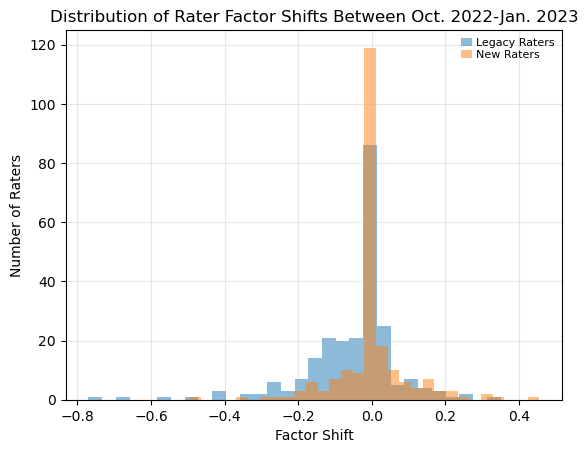

In [22]:
plt.hist(legacy_shift_2022['factor_shift'], bins=30, alpha=0.5, label='Legacy Raters', color='tab:blue')
plt.hist(new_shift_2022['factor_shift'],    bins=30, alpha=0.5, label='New Raters',    color='tab:orange')
plt.xlabel('Factor Shift')
plt.ylabel('Number of Raters')
plt.title('Distribution of Rater Factor Shifts Between Oct. 2022-Jan. 2023')
plt.grid(True, which="both", axis="both", alpha=0.3)
plt.legend(
    fontsize=8,
    title_fontsize=9,
    frameon=False,
    labelspacing=0.2,
    handlelength=1.0,
    handletextpad=0.3,
    borderpad=0.2
)
plt.savefig("final_code/appendix-figures/rater_factor_shift_hist_2022.png", dpi=300, bbox_inches="tight")

In [23]:
legacy_mean = legacy_shift_2022["factor_shift"].mean()
new_mean    = new_shift_2022["factor_shift"].mean()
diff_means  = legacy_mean - new_mean

print(f"Legacy mean factor_shift: {legacy_mean:.6f}")
print(f"New mean factor_shift:    {new_mean:.6f}")
print(f"Difference (Legacy - New): {diff_means:.6f}")

Legacy mean factor_shift: -0.049158
New mean factor_shift:    0.003234
Difference (Legacy - New): -0.052392


In [25]:
rng = np.random.default_rng(0)
B = 10000  # bootstrap reps

x = legacy_shift_2022["factor_shift"].dropna().to_numpy()
y = new_shift_2022["factor_shift"].dropna().to_numpy()

# Bootstrap means for each group
x_boot_means = rng.choice(x, size=(B, x.size), replace=True).mean(axis=1)
y_boot_means = rng.choice(y, size=(B, y.size), replace=True).mean(axis=1)

x_mean = x.mean()
y_mean = y.mean()

x_ci_low, x_ci_high = np.percentile(x_boot_means, [2.5, 97.5])
y_ci_low, y_ci_high = np.percentile(y_boot_means, [2.5, 97.5])

print(f"Legacy mean factor_shift: {x_mean:.6f} (n={x.size})")
print(f"95% bootstrap CI:         [{x_ci_low:.6f}, {x_ci_high:.6f}]")
print()
print(f"New mean factor_shift:    {y_mean:.6f} (n={y.size})")
print(f"95% bootstrap CI:         [{y_ci_low:.6f}, {y_ci_high:.6f}]")


Legacy mean factor_shift: -0.049158 (n=237)
95% bootstrap CI:         [-0.066540, -0.032450]

New mean factor_shift:    0.003234 (n=218)
95% bootstrap CI:         [-0.010110, 0.016523]


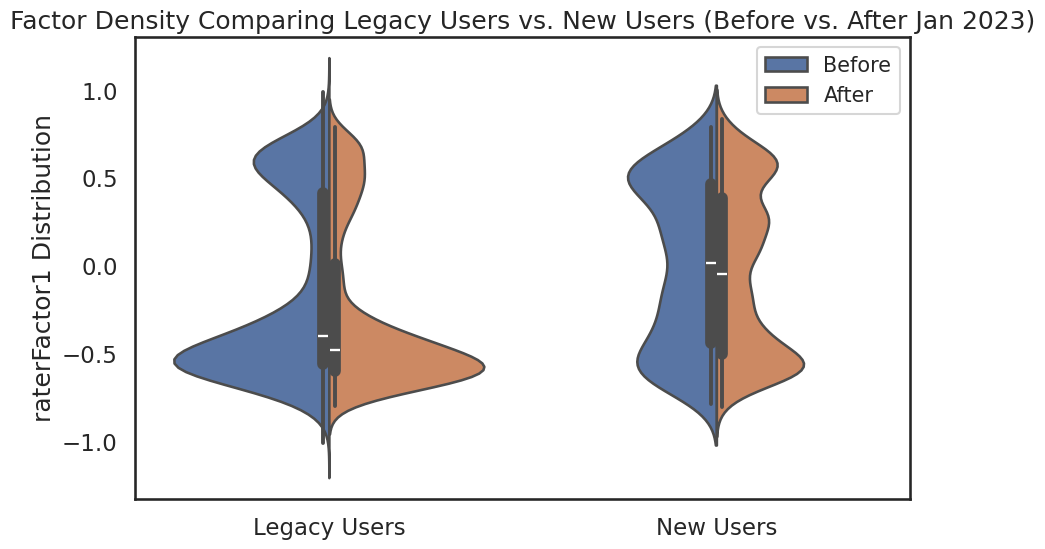

In [159]:
rater_df_legacy = rater_df[rater_df['raterParticipantId'].isin(legacy_users)]
rater_df_new = rater_df[rater_df['raterParticipantId'].isin(new_users)]

date_col = "week_dt" 
cutoff = pd.Timestamp("2023-01-01")

# ensure datetime
rater_df_legacy = rater_df_legacy.copy()
rater_df_new    = rater_df_new.copy()
rater_df_legacy[date_col] = pd.to_datetime(rater_df_legacy[date_col])
rater_df_new[date_col]    = pd.to_datetime(rater_df_new[date_col])

# add labels
rater_df_legacy["Cohort"] = "Legacy Users"
rater_df_new["Cohort"]    = "New Users"

rater_df_legacy["Period"] = pd.Series(pd.NA, index=rater_df_legacy.index)
rater_df_new["Period"]    = pd.Series(pd.NA, index=rater_df_new.index)

rater_df_legacy["Period"] = (rater_df_legacy[date_col] < cutoff).map({True: "Before", False: "After"})
rater_df_new["Period"]    = (rater_df_new[date_col]    < cutoff).map({True: "Before", False: "After"})

rater_df_cohort = pd.concat(
    [rater_df_legacy[["Cohort", "Period", "raterFactor1"]],
     rater_df_new[["Cohort", "Period", "raterFactor1"]]],
    ignore_index=True
).dropna(subset=["raterFactor1", "Period"])

# plot
plt.figure(figsize=(10,6))
sns.violinplot(
    data=rater_df_cohort,
    x="Cohort", 
    y="raterFactor1", 
    hue="Period",
    split=True,
    inner="box"
)
plt.title("Factor Density Comparing Legacy Users vs. New Users (Before vs. After Jan 2023)")
plt.ylabel("raterFactor1 Distribution")
plt.xlabel("")
plt.legend(loc='upper right', fontsize='small')

# Save before showing
plt.savefig("final_code/appendix-figures/rater_factor_violin_plot_2022.png", dpi=300, bbox_inches="tight")
# plt.savefig("violin_plot.pdf", bbox_inches="tight")   # for papers

plt.show()

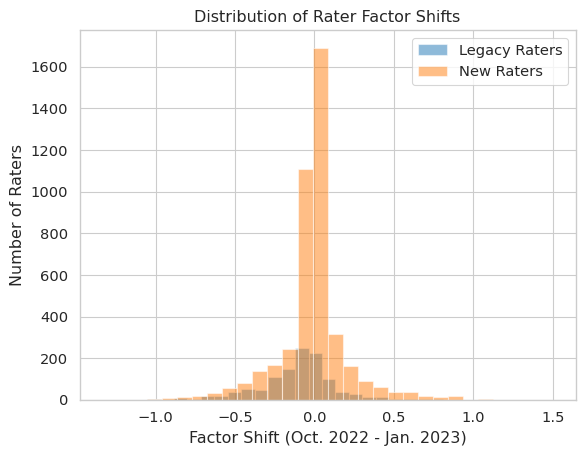

In [130]:
plt.hist(legacy_shift_2025['factor_shift'], bins=30, alpha=0.5, label='Legacy Raters')
plt.hist(new_shift_2025['factor_shift'], bins=30, alpha=0.5, label='New Raters')
plt.xlabel('Factor Shift (Oct. 2022 - Jan. 2023)')
plt.ylabel('Number of Raters')
plt.title('Distribution of Rater Factor Shifts')
plt.savefig("final_code/appendix-figures/rater_factor_shift_hist_2025.png", dpi=300, bbox_inches="tight")
plt.legend()

# User-Note Alignment

In [13]:
def prepare_rating_factors_over_time_weekly(ratings_df, note_df, rater_df):
    # Add week column to ratings
    rater_df['week_dt'] = pd.to_datetime(rater_df['week_dt']).dt.normalize()
    note_df['week_dt'] = pd.to_datetime(note_df['week_dt']).dt.normalize()
    ratings_df['week_dt'] = pd.to_datetime(ratings_df['createdAtMillis'], unit='ms').dt.to_period('W').dt.start_time

    
    # Ensure note_df and rater_df also have 'week' column
    if 'week_dt' not in note_df.columns or 'week_dt' not in rater_df.columns:
        raise ValueError("note_df and rater_df must include a 'week' column for weekly merging.")
    
    ratings_df = ratings_df.sort_values(['week_dt'])
    note_df = note_df.sort_values([ 'week_dt'])
    rater_df = rater_df.sort_values(["week_dt"])

    # Merge_asof for note factors
    df = pd.merge_asof(
        ratings_df,
        note_df[['noteId', 'noteFactor1', 'noteIntercept', 'week_dt']],
        by='noteId',
        left_on='week_dt',
        right_on='week_dt',
        direction='backward',
        allow_exact_matches=False
    )

    # Ensure participant IDs are the same type (string is usually safest)
    rater_df["raterParticipantId"] = rater_df["raterParticipantId"].astype(str)
    df["raterParticipantId"] = df["raterParticipantId"].astype(str)
    
    # Merge with rater factors by raterParticipantId and week
    df = pd.merge_asof(
        left=df,
        right=rater_df[["raterParticipantId", "week_dt", "raterFactor1", 'raterIntercept']],
        by="raterParticipantId",
        left_on="week_dt",
        right_on="week_dt",
        direction="backward",
        allow_exact_matches=False
    )

    # Convert labels
    df['helpful_binary'] = np.where(
        df['helpfulnessLevel'] == 'HELPFUL', 1,
        np.where(df['helpfulnessLevel'] == 'NOT_HELPFUL', 0, np.nan)
    )

    # # Clean up
    df = df.dropna(subset=['noteFactor1', 'raterFactor1', 'helpful_binary'])

    # Label for coloring
    df['vote_label'] = df['helpful_binary'].map({1: 'Helpful', 0: 'Not Helpful'})

    return df


# Prepare data
df_plot = prepare_rating_factors_over_time_weekly(ratings_df, note_df_full_2025, rater_df_2025)

In [14]:
df_plot.head()

,noteId,raterParticipantId,createdAtMillis,helpfulnessLevel,createdAtDate,week_dt,noteFactor1,noteIntercept,raterFactor1,raterIntercept,helpful_binary,vote_label
8611,1434773333359284224,8A2C6A27C1C09B68800C34B3C40F6B53DDB79378C3B038...,1659928769905,HELPFUL,2022-08-08 03:19:29.905,2022-08-08,-0.788607,0.135535,-0.581292,0.258333,1.0,Helpful
8613,1434660539813269513,8A2C6A27C1C09B68800C34B3C40F6B53DDB79378C3B038...,1659928802146,HELPFUL,2022-08-08 03:20:02.146,2022-08-08,-0.769889,0.126790,-0.581292,0.258333,1.0,Helpful
8670,1433290414082113538,6EEB94032F425636CC4475292D77127A69C350658077B4...,1660071103784,NOT_HELPFUL,2022-08-09 18:51:43.784,2022-08-08,0.523291,0.180286,-0.527169,0.278380,0.0,Not Helpful
8747,1545605017444524035,269CDF389F42840CCDA5444D6AB187440DD3FB91B60E79...,1660487460940,HELPFUL,2022-08-14 14:31:00.940,2022-08-08,-0.643198,0.223656,-0.694474,0.117382,1.0,Helpful
9145,1549795651797471233,65F687F3F0BE41BB456A883BA989742AB6F9566B731F75...,1660194229659,NOT_HELPFUL,2022-08-11 05:03:49.659,2022-08-08,0.278619,-0.015160,-0.726363,0.099647,0.0,Not Helpful


In [24]:
len(legacy_users)

1202

In [15]:
start = '2022-08-01'
end = '2023-01-01'

cutoff = '2022-10-01'

df_plot['week_dt'] = pd.to_datetime(df_plot['week_dt'])
df_plot = df_plot[(df_plot['week_dt'] >= start) & (df_plot['week_dt'] <= end)]
df_plot['dot_product'] = df_plot["noteFactor1"] * df_plot["raterFactor1"]
df_plot_legacy = df_plot[df_plot['raterParticipantId'].isin(legacy_users)]

df_plot_legacy.shape

(329, 13)

Corr before: 0.7921
Corr after: 0.5251
Observed diff: -0.2670
P-value: 0.0040


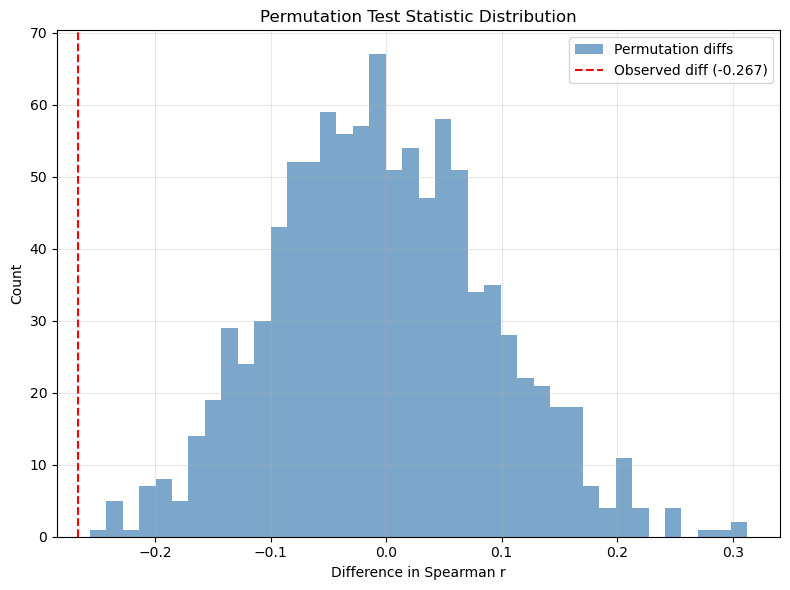

In [21]:
from scipy.stats import spearmanr

before = df_plot_legacy[df_plot_legacy['week_dt'] < cutoff]
after = df_plot_legacy[df_plot_legacy['week_dt'] > cutoff]

corr_before = spearmanr(before['dot_product'], before['helpful_binary']).correlation
corr_after = spearmanr(after['dot_product'], after['helpful_binary']).correlation
observed_diff = corr_after - corr_before
print(f'Corr before: {corr_before:.4f}')
print(f'Corr after: {corr_after:.4f}')
print(f'Observed diff: {observed_diff:.4f}')

# Permutation test
all_data = pd.concat([before, after]).reset_index(drop=True)
n_before = len(before)
perm_diffs = []

for _ in range(1000):
    shuffled = all_data.sample(frac=1).reset_index(drop=True)
    perm_before = shuffled.iloc[:n_before]
    perm_after = shuffled.iloc[n_before:]
    
    c_before = spearmanr(perm_before['dot_product'], perm_before['helpful_binary']).correlation
    c_after = spearmanr(perm_after['dot_product'], perm_after['helpful_binary']).correlation
    perm_diffs.append(c_after - c_before)

perm_diffs = np.array(perm_diffs)
p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
print(f'P-value: {p_value:.4f}')

# Plot permutation distribution
plt.figure(figsize=(8, 6))
plt.hist(perm_diffs, bins=40, color='steelblue', alpha=0.7, label='Permutation diffs')
plt.axvline(observed_diff, color='red', linestyle='--', label=f'Observed diff ({observed_diff:.3f})')
plt.title('Permutation Test Statistic Distribution')
plt.xlabel('Difference in Spearman r')
plt.ylabel('Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("final_code/figures/permutation_spearman.png", dpi=300, bbox_inches="tight")
plt.show()

In [32]:
df_plot_legacy['post'] = (df_plot_legacy['week_dt'] >= pd.to_datetime(cutoff)).astype(int)

model = smf.ols(
    'helpful_binary ~ dot_product + post + post:dot_product',
    data=df_plot_legacy
).fit(cov_type='HC3')

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         helpful_binary   R-squared:                       0.350
Model:                            OLS   Adj. R-squared:                  0.344
Method:                 Least Squares   F-statistic:                     191.0
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           2.16e-71
Time:                        11:55:22   Log-Likelihood:                -160.96
No. Observations:                 329   AIC:                             329.9
Df Residuals:                     325   BIC:                             345.1
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.4937      0.039  

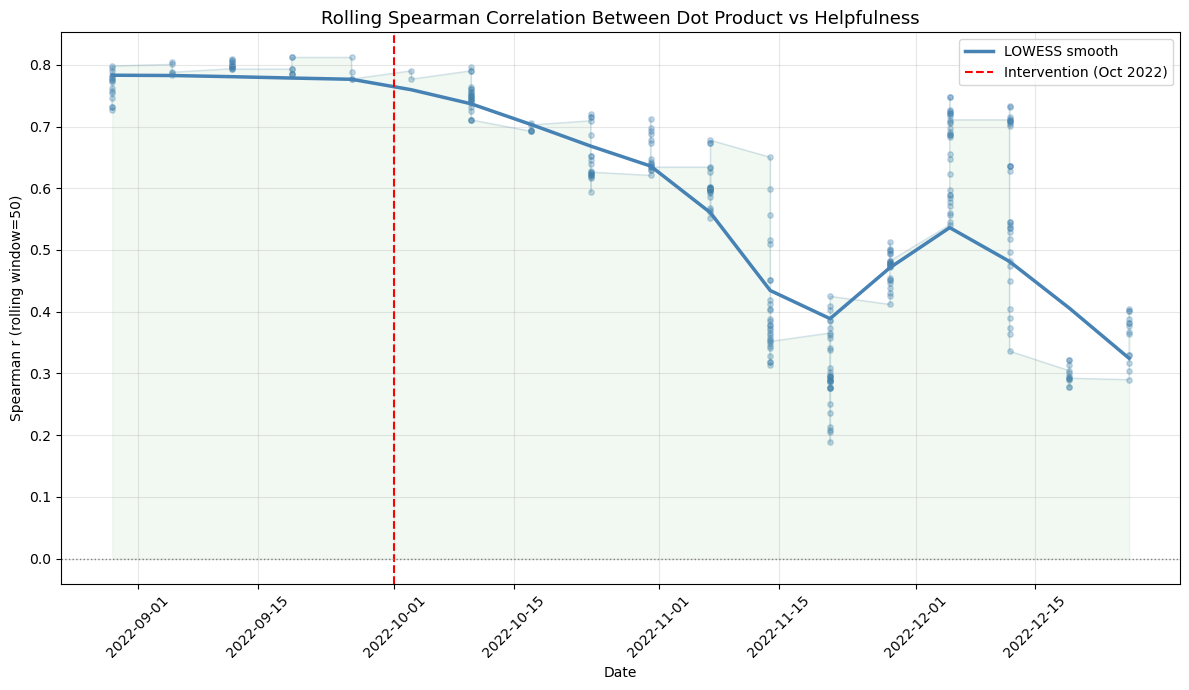

In [22]:
from statsmodels.nonparametric.smoothers_lowess import lowess

df_plot_legacy = df_plot_legacy.sort_values('week_dt').reset_index(drop=True)


window = 50
min_periods = 20
rolling_spearman = []
for i in range(len(df_plot_legacy)):
    start_i = max(0, i - window)
    window_data = df_plot_legacy.iloc[start_i:i+1]
    if len(window_data) < min_periods:
        rolling_spearman.append(np.nan)
    else:
        corr, _ = spearmanr(window_data['dot_product'], window_data['helpful_binary'])
        rolling_spearman.append(corr)

df_plot_legacy['rolling_corr'] = rolling_spearman
df_plot_legacy['rolling_corr'] = df_plot_legacy['rolling_corr'].clip(-1, 1)

# LOWESS smooth
valid = df_plot_legacy['rolling_corr'].dropna()
valid_dates = df_plot_legacy.loc[valid.index, 'week_dt']
smoothed = lowess(valid.values, valid_dates.astype(np.int64), frac=0.3)
smoothed_dates = pd.to_datetime(smoothed[:, 0])

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(df_plot_legacy['week_dt'], df_plot_legacy['rolling_corr'],
           alpha=0.3, s=15, color='steelblue')
ax.plot(df_plot_legacy['week_dt'], df_plot_legacy['rolling_corr'],
        alpha=0.2, color='steelblue', linewidth=1)
ax.plot(smoothed_dates, smoothed[:, 1],
        color='steelblue', linewidth=2.5, label='LOWESS smooth')
ax.axvline(pd.to_datetime(cutoff), linestyle='--', color='red', linewidth=1.5, label='Intervention (Oct 2022)')
ax.axhline(0, linestyle=':', color='gray', linewidth=1)
ax.fill_between(df_plot_legacy['week_dt'], df_plot_legacy['rolling_corr'], 0,
                where=df_plot_legacy['rolling_corr'] > 0,
                alpha=0.05, color='green')
ax.fill_between(df_plot_legacy['week_dt'], df_plot_legacy['rolling_corr'], 0,
                where=df_plot_legacy['rolling_corr'] < 0,
                alpha=0.05, color='red')
ax.set_title('Rolling Spearman Correlation Between Dot Product vs Helpfulness', fontsize=13)
ax.set_ylabel('Spearman r (rolling window=50)')
ax.set_xlabel('Date')
ax.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("final_code/figures/spearman-correlation-visualization.png", dpi=300, bbox_inches="tight")
plt.show()

15.695666273372773
4.42689359385481
-11.268772679517962
Observed diff: -11.2688
P-value: 0.0010


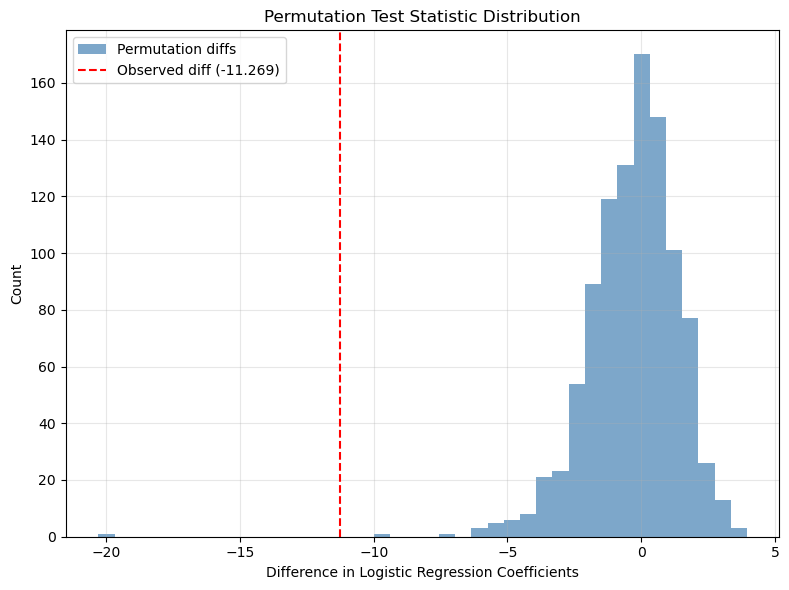

In [25]:
before = df_plot_legacy[df_plot_legacy['week_dt'] < cutoff]
after = df_plot_legacy[df_plot_legacy['week_dt'] > cutoff]

# run logistic regression, record difference in predictive power
X_before = sm.add_constant(before['dot_product'])
y_before = before['helpful_binary']
model_before = sm.Logit(y_before, X_before).fit(disp=0)
coef_before = model_before.params['dot_product']


X_after = sm.add_constant(after['dot_product'])
y_after = after['helpful_binary']
model_after = sm.Logit(y_after, X_after).fit(disp=0)
coef_after = model_after.params['dot_product']
diff = coef_after - coef_before
print(coef_before)
print(coef_after)
print(diff)

all_data = df_plot_legacy
n_before = len(before)

observed_diff = coef_after - coef_before
perm_diffs = []

# do permutation test
for _ in range(1000):
    shuffled = all_data.sample(frac=1).reset_index(drop=True)
    perm_before = shuffled.iloc[:n_before]
    perm_after = shuffled.iloc[n_before:]
    
    try:
        m_before = sm.Logit(perm_before['helpful_binary'], 
                            sm.add_constant(perm_before['dot_product'])).fit(disp=0)
        m_after = sm.Logit(perm_after['helpful_binary'], 
                           sm.add_constant(perm_after['dot_product'])).fit(disp=0)
        perm_diffs.append(m_after.params['dot_product'] - m_before.params['dot_product'])
    except:
        continue

perm_diffs = np.array(perm_diffs)
p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
print(f'Observed diff: {observed_diff:.4f}')
print(f'P-value: {p_value:.4f}')

# Plot permutation distribution
plt.figure(figsize=(8, 6))
plt.hist(perm_diffs, bins=40, color='steelblue', alpha=0.7, label='Permutation diffs')
plt.axvline(observed_diff, color='red', linestyle='--', label=f'Observed diff ({observed_diff:.3f})')
plt.title('Permutation Test Statistic Distribution')
plt.xlabel('Difference in Logistic Regression Coefficients')
plt.ylabel('Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("final_code/figures/permutation_logistic.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
weekly_coefs = []
start = '2022-08-01'
end = '2023-01-01'
df_plot['week_dt'] = pd.to_datetime(df_plot['week_dt'])
df_plot = df_plot[(df_plot['week_dt'] >= start) & (df_plot['week_dt'] <= end)]
df_plot['dot_product'] = df_plot["noteFactor1"] * df_plot["raterFactor1"]
df_plot_legacy = df_plot[df_plot['raterParticipantId'].isin(legacy_users)]
df_plot_legacy = df_plot_legacy.set_index('week_dt')

for period, group in df_plot.groupby(pd.Grouper(freq='4W')):
    if group.empty:
        continue
    try:
        X = sm.add_constant(group['dot_product'])
        y = group['helpful_binary']
        model = sm.Logit(y, X).fit(disp=0)
        coef = model.params['dot_product']
        weekly_coefs.append((period, coef))
    except Exception as e:
        print(f'skipped {period}: {e}')
        continue

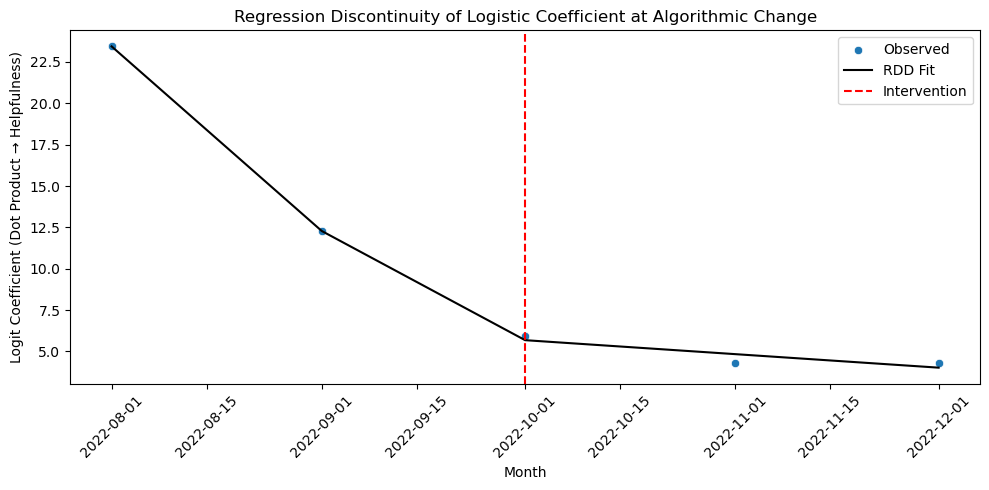

In [68]:
# run RDD on the monthly logistic regression coefficient
monthly_coef_df['month'] = pd.to_datetime(monthly_coef_df['month'])
monthly_coef_df['month_num'] = monthly_coef_df['month'].map(pd.Timestamp.toordinal)

# Set cutoff at Oct 1, 2022
cutoff = pd.to_datetime("2022-10-01").toordinal()
monthly_coef_df['running'] = monthly_coef_df['month_num'] - cutoff
monthly_coef_df['post'] = (monthly_coef_df['running'] >= 0).astype(int)

# Fit RDD model
model = smf.ols('coefficient ~ running + post + running:post', data=monthly_coef_df).fit(cov_type='HC1')

# Add predictions
monthly_coef_df['fitted'] = model.fittedvalues

# Plot
plt.figure(figsize=(10, 5))
sns.scatterplot(data=monthly_coef_df, x='month', y='coefficient', label='Observed')
sns.lineplot(data=monthly_coef_df, x='month', y='fitted', color='black', label='RDD Fit')
plt.axvline(pd.to_datetime("2022-10-01"), linestyle='--', color='red', label='Intervention')
plt.title('Regression Discontinuity of Logistic Coefficient at Algorithmic Change')
plt.ylabel('Logit Coefficient (Dot Product → Helpfulness)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

# Save the plot to file (before showing)
# plt.savefig("final_code/figures/rdd_monthly_coef_2025.png", dpi=300, bbox_inches="tight")

plt.show()

# Annotations on Controversial Topics

In [14]:
history_df["noteId"]=history_df["noteId"].astype(int)

CONTROVERSIAL_TOPICS = [
    'USPolitics', 'UkraineConflict', 'GazaConflict',
    'CrimeLegal', 'HealthCovid', 'EconomyFinance','MessiRonaldo',  'politics', 'economy', 'health'
]

NON_CONTROVERSIAL_TOPICS = [
    'SpaceAstronomy', 'ClimateEnvironment', 'EntertainmentMoviesTV',
    'WeatherDisasters', 'TechCompanies', 'SportsNFL', 'SportsNBA',
'FoodNutrition', 'Education', 'Scams',
    'ArtificialIntelligence', 'science', 'other'
]

notes_df_topic["controversial"] = np.select(
    [
        notes_df_topic['noteTopic'].isin(CONTROVERSIAL_TOPICS),
        notes_df_topic['noteTopic'].isin(NON_CONTROVERSIAL_TOPICS),
    ],
    ["Controversial", "Non-Controversial"],
    default=pd.NA,
)

In [15]:
def _wilson_ci(k, n, z=1.96):
    """Wilson score interval for a binomial proportion."""
    k = np.asarray(k, dtype=float)
    n = np.asarray(n, dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        phat = np.where(n > 0, k / n, np.nan)
        denom = 1 + z**2 / n
        center = (phat + (z**2) / (2*n)) / denom
        margin = (z * np.sqrt((phat*(1-phat)/n) + (z**2)/(4*n**2))) / denom
        lo = center - margin
        hi = center + margin
    return lo, hi

def _weighted_centered_rolling(values, weights, window):
    """Centered, weight-aware rolling mean (nan-safe)."""
    s = pd.Series(values, dtype=float)
    w = pd.Series(weights, dtype=float)
    def _avg(x):
        v = x.values
        ww = w.iloc[x.index].values
        mask = ~np.isnan(v) & ~np.isnan(ww) & (ww > 0)
        return np.average(v[mask], weights=ww[mask]) if mask.any() else np.nan
    return s.rolling(window=window, center=True, min_periods=1).apply(_avg, raw=False)

In [16]:
notes_df_topic.head()

,noteId,noteAuthorParticipantId,createdAtMillis,tweetId,classification,believable,harmful,validationDifficulty,misleadingOther,misleadingFactualError,...,notMisleadingFactuallyCorrect,notMisleadingOutdatedButNotWhenWritten,notMisleadingClearlySatire,notMisleadingPersonalOpinion,trustworthySources,summary,isMediaNote,week_dt,noteTopic,controversial
0,1783179305159200982,C784F04F26E124F4D6EC01658D8F5565005D3092741FB3...,1713978050878,1783159712986382830,MISINFORMED_OR_POTENTIALLY_MISLEADING,NaN,NaN,NaN,0,0,...,0,0,0,0,1,The House failed to pass a border protection l...,0.0,2024-04-22,USPolitics,Controversial
1,1883711635770196070,C784F04F26E124F4D6EC01658D8F5565005D3092741FB3...,1737946826294,1883619411774345444,MISINFORMED_OR_POTENTIALLY_MISLEADING,NaN,NaN,NaN,1,0,...,0,0,0,0,1,This could be considered a threat https://...,0.0,2025-01-27,Scams,Non-Controversial
2,1537142913737428992,5684B38EB58FD8BE75ABA37F0BE040EC70380B002ADF9D...,1655318404027,1377030478167937024,MISINFORMED_OR_POTENTIALLY_MISLEADING,BELIEVABLE_BY_MANY,CONSIDERABLE_HARM,EASY,0,1,...,0,0,0,0,1,Forbes has a good rundown of the investigation...,0.0,2022-06-13,USPolitics,Controversial
3,1537147343715282945,5684B38EB58FD8BE75ABA37F0BE040EC70380B002ADF9D...,1655319460217,1537080831751102467,MISINFORMED_OR_POTENTIALLY_MISLEADING,BELIEVABLE_BY_MANY,LITTLE_HARM,EASY,0,0,...,0,0,0,0,1,Teslas purchased after 12/31/19 are not eligib...,0.0,2022-06-13,SpaceAstronomy,Non-Controversial
4,1537204430730211328,5684B38EB58FD8BE75ABA37F0BE040EC70380B002ADF9D...,1655333070821,1537196168953974784,MISINFORMED_OR_POTENTIALLY_MISLEADING,BELIEVABLE_BY_MANY,CONSIDERABLE_HARM,EASY,0,1,...,0,0,0,0,1,The Jan 6th riots were encouraged by the sitti...,0.0,2022-06-13,USPolitics,Controversial


In [59]:
def calculate_controversy_proportions_principled(
    status_history_df: pd.DataFrame,
    notes_df: pd.DataFrame,
    note_topic_col: str='noteTopic',
    time: str = "W",
    min_n: int = 30,               # hide points with fewer than min_n denominators
    smooth_window: int = 7,        # centered window length for smoothing
    jeffreys_alpha: float = 0.5,   # Jeffreys prior for shrinkage
    jeffreys_beta: float = 0.5
) -> pd.DataFrame:
    """
    Weekly proportions by topic category with:
      - category-specific denominators (unique tweets seeing their first note in that category)
      - Jeffreys-shrunk proportions to stabilize small n
      - Wilson 95% CIs
      - weighted, centered rolling smoothing (by denominator)
      - NaN where denominator < min_n (kept for plotting masks)
    """
    # Merge & prepare
    df = pd.merge(status_history_df, notes_df, on='noteId', how='right',
                  suffixes=('_status', '_note'))

    print(df.columns)
    df['note_creation_dt'] = pd.to_datetime(df['createdAtMillis_note'], unit='ms')

    df['topic_category'] = df[note_topic_col].apply(
        lambda x: 'Controversial' if x in CONTROVERSIAL_TOPICS
        else ('Non-Controversial' if x in NON_CONTROVERSIAL_TOPICS else 'Other')
    )

    out = []

    for category in df['topic_category'].dropna().unique():
        cdf = df[df['topic_category'] == category]

        # denominator: first time each tweet gets ANY note in this category
        denom_idx = cdf.groupby('tweetId')['note_creation_dt'].min()
        denom = denom_idx.value_counts().resample(time).sum().fillna(0).rename('denominator_tweets')

        # helpful / unhelpful: first time each tweet gets a note with that final status in this category
        helpful_first = cdf[cdf['currentStatus'] == 'CURRENTLY_RATED_HELPFUL'] \
                          .groupby('tweetId')['note_creation_dt'].min()
        unhelpful_first = cdf[cdf['currentStatus'] == 'CURRENTLY_RATED_NOT_HELPFUL'] \
                          .groupby('tweetId')['note_creation_dt'].min()

        helpful = helpful_first.value_counts().resample(time).sum().reindex(denom.index).fillna(0).rename(f'helpful_{category}')
        unhelpful = unhelpful_first.value_counts().resample(time).sum().reindex(denom.index).fillna(0).rename(f'unhelpful_{category}')

        # raw proportions (nan where n=0)
        with np.errstate(divide='ignore', invalid='ignore'):
            p_help = np.where(denom.values > 0, helpful.values / denom.values, np.nan)
            p_unhl = np.where(denom.values > 0, unhelpful.values / denom.values, np.nan)

        # Jeffreys-shrunk estimates
        ph_shrunk = (helpful.values + jeffreys_alpha) / (denom.values + jeffreys_alpha + jeffreys_beta)
        pu_shrunk = (unhelpful.values + jeffreys_alpha) / (denom.values + jeffreys_alpha + jeffreys_beta)
        ph_shrunk = np.where(denom.values > 0, ph_shrunk, np.nan)
        pu_shrunk = np.where(denom.values > 0, pu_shrunk, np.nan)

        # Wilson CIs (on raw proportions)
        ph_lo, ph_hi = _wilson_ci(helpful.values, denom.values)
        pu_lo, pu_hi = _wilson_ci(unhelpful.values, denom.values)

        # mask tiny denominators
        mask = denom.values >= min_n
        def _mask(arr):
            arr = np.asarray(arr, dtype=float)
            arr[~mask] = np.nan
            return arr

        # smooth (weighted by denominators)
        ph_smooth = _weighted_centered_rolling(_mask(ph_shrunk), denom.values, smooth_window)
        pu_smooth = _weighted_centered_rolling(_mask(pu_shrunk), denom.values, smooth_window)

        cat_df = pd.DataFrame({
            'week_dt': denom.index,
            'denominator_tweets_' + category: denom.values,
            f'helpful_{category}': helpful.values,
            f'unhelpful_{category}': unhelpful.values,
            f'prop_helpful_raw_{category}': _mask(p_help),
            f'prop_unhelpful_raw_{category}': _mask(p_unhl),
            f'prop_helpful_shrunk_{category}': _mask(ph_shrunk),
            f'prop_unhelpful_shrunk_{category}': _mask(pu_shrunk),
            f'prop_helpful_lo_{category}': _mask(ph_lo),
            f'prop_helpful_hi_{category}': _mask(ph_hi),
            f'prop_unhelpful_lo_{category}': _mask(pu_lo),
            f'prop_unhelpful_hi_{category}': _mask(pu_hi),
            f'prop_helpful_smooth_{category}': ph_smooth.values,
            f'prop_unhelpful_smooth_{category}': pu_smooth.values,
        })
        out.append(cat_df)

    # outer-merge all categories on week_dt
    result = out[0]
    for k in out[1:]:
        result = pd.merge(result, k, on='week_dt', how='outer')

    result = result.sort_values('week_dt').reset_index(drop=True)
    return df, result


# --- usage -----------------------------------------------------------------
l_df, p_df = calculate_controversy_proportions_principled(history_df,
                                                    notes_df_topic_llm,
                                                    note_topic_col='LLAMA4',
                                                    time="W",
                                                    min_n=6, smooth_window=9)

Index(['noteId', 'noteAuthorParticipantId_status', 'createdAtMillis_status',
       'timestampMillisOfFirstNonNMRStatus', 'firstNonNMRStatus',
       'timestampMillisOfCurrentStatus', 'currentStatus',
       'timestampMillisOfLatestNonNMRStatus', 'mostRecentNonNMRStatus',
       'timestampMillisOfStatusLock', 'lockedStatus',
       'timestampMillisOfRetroLock', 'currentCoreStatus',
       'currentExpansionStatus', 'currentGroupStatus', 'currentDecidedBy',
       'currentModelingGroup', 'timestampMillisOfMostRecentStatusChange',
       'timestampMillisOfNmrDueToMinStableCrhTime', 'currentMultiGroupStatus',
       'currentModelingMultiGroup', 'timestampMinuteOfFinalScoringOutput',
       'timestampMillisOfFirstNmrDueToMinStableCrhTime',
       'noteAuthorParticipantId_note', 'createdAtMillis_note', 'tweetId',
       'classification', 'believable', 'harmful', 'validationDifficulty',
       'misleadingOther', 'misleadingFactualError',
       'misleadingManipulatedMedia', 'misleadingOutdate

In [44]:
# preprocess df
# notes_df_topic_llm = notes_df_topic.merge(notes_df_llms, left_on='noteId', right_on='NOTEID')
notes_df_topic_llm['TOPIC'] = notes_df_topic_llm['TOPIC'].str.replace(' ', '', regex=False)
notes_df_topic_llm['LLAMA4'] = notes_df_topic_llm['LLAMA4'].str.replace(' ', '', regex=False)

In [47]:
p_df.head()

,week_dt,denominator_tweets_Controversial,helpful_Controversial,unhelpful_Controversial,prop_helpful_raw_Controversial,prop_unhelpful_raw_Controversial,prop_helpful_shrunk_Controversial,prop_unhelpful_shrunk_Controversial,prop_helpful_lo_Controversial,prop_helpful_hi_Controversial,...,prop_helpful_raw_Other,prop_unhelpful_raw_Other,prop_helpful_shrunk_Other,prop_unhelpful_shrunk_Other,prop_helpful_lo_Other,prop_helpful_hi_Other,prop_unhelpful_lo_Other,prop_unhelpful_hi_Other,prop_helpful_smooth_Other,prop_unhelpful_smooth_Other
0,2021-01-31,52,4,1,0.076923,0.019231,0.084906,0.028302,0.030319,0.181738,...,0.000000,0.041667,0.020000,0.060000,0.000000e+00,0.137981,7.393265e-03,0.202422,0.040525,0.040803
1,2021-02-07,35,1,1,0.028571,0.028571,0.041667,0.041667,0.005061,0.145334,...,0.000000,0.000000,0.026316,0.026316,0.000000e+00,0.175885,0.000000e+00,0.175885,0.041876,0.042129
2,2021-02-14,25,0,0,0.000000,0.000000,0.019231,0.019231,0.000000,0.133196,...,0.000000,0.000000,0.035714,0.035714,0.000000e+00,0.228102,0.000000e+00,0.228102,0.037555,0.037756
3,2021-02-21,18,1,0,0.055556,0.000000,0.078947,0.026316,0.009875,0.257578,...,0.066667,0.000000,0.093750,0.031250,1.186659e-02,0.298171,-1.387779e-17,0.203889,0.045087,0.037824
4,2021-02-28,16,0,0,0.000000,0.000000,0.029412,0.029412,0.000000,0.193613,...,0.000000,0.000000,0.041667,0.041667,2.775558e-17,0.258840,2.775558e-17,0.258840,0.040583,0.029772



Summary of mean helpfulness and 95% CI (Wilson):
  Controversial |  Pre | mean = 0.061, 95% CI = [0.042, 0.089]
  Controversial | Post | mean = 0.127, 95% CI = [0.106, 0.151]
Non-Controversial |  Pre | mean = 0.051, 95% CI = [0.020, 0.123]
Non-Controversial | Post | mean = 0.183, 95% CI = [0.138, 0.238]


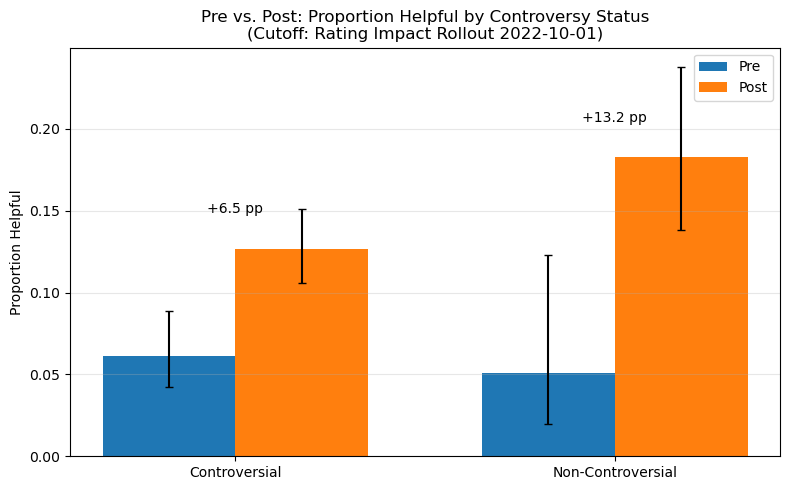

In [60]:
# --- utility: Wilson CI for aggregated counts ------------------------------
def wilson_ci_agg(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    phat = k / n
    denom = 1 + z**2 / n
    center = (phat + (z**2) / (2*n)) / denom
    margin = (z * np.sqrt((phat*(1-phat)/n) + (z**2)/(4*n**2))) / denom
    return center - margin, center + margin

# --- main: pre/post aggregated proportions + plot --------------------------
def plot_pre_post_helpful_difference(
    df_weekly: pd.DataFrame,
    cutoff_date: str = "2022-10-01",
    categories = ("Controversial", "Non-Controversial"),
    title = "Pre vs. Post: Proportion Helpful by Controversy Status",
    path = "final_code/figures/",
    suffix: str = ""
):
    """
    df_weekly: output of calculate_controversy_proportions_principled(...)
               must include columns:
               - 'week_dt'
               - 'denominator_tweets_{cat}'
               - 'helpful_{cat}'
    """
    cutoff = pd.to_datetime(cutoff_date)
    df = df_weekly.copy()
    df = df.sort_values("week_dt")
    df["period"] = np.where(df["week_dt"] < cutoff, "Pre", "Post")

    # aggregate counts by period and category
    rows = []
    for cat in categories:
        dcol = f"denominator_tweets_{cat}"
        hcol = f"helpful_{cat}"
        # guard for missing columns
        if dcol not in df.columns or hcol not in df.columns:
            raise KeyError(f"Expected columns '{dcol}' and '{hcol}' not found in dataframe.")
        for period, g in df.groupby("period"):
            n = np.nansum(g[dcol].values)
            k = np.nansum(g[hcol].values)
            p = (k / n) if n > 0 else np.nan
            lo, hi = wilson_ci_agg(k, n)
            rows.append({
                "category": cat,
                "period": period,
                "k_helpful": k,
                "n_den": n,
                "prop_helpful": p,
                "ci_lo": lo,
                "ci_hi": hi
            })
    agg = pd.DataFrame(rows)

    print("\nSummary of mean helpfulness and 95% CI (Wilson):")
    for cat in categories:
        for period in ["Pre", "Post"]:
            row = agg[(agg["category"] == cat) & (agg["period"] == period)]
            if not row.empty:
                p = row["prop_helpful"].values[0]
                lo = row["ci_lo"].values[0]
                hi = row["ci_hi"].values[0]
                print(f"{cat:>15} | {period:>4} | mean = {p:.3f}, 95% CI = [{lo:.3f}, {hi:.3f}]")

    # compute change (Post - Pre) for label
    change = (
        agg.pivot(index="category", columns="period", values="prop_helpful")
           .assign(change=lambda x: x["Post"] - x["Pre"])
           .reset_index()
    )

    # plot grouped bars with error bars
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(categories))
    width = 0.35

    pre = agg[agg["period"] == "Pre"].set_index("category").loc[list(categories)]
    post = agg[agg["period"] == "Post"].set_index("category").loc[list(categories)]

    pre_bars = ax.bar(x - width/2, pre["prop_helpful"].values, width,
                      yerr=[pre["prop_helpful"].values - pre["ci_lo"].values,
                            pre["ci_hi"].values - pre["prop_helpful"].values],
                      capsize=3, label="Pre")
    post_bars = ax.bar(x + width/2, post["prop_helpful"].values, width,
                       yerr=[post["prop_helpful"].values - post["ci_lo"].values,
                             post["ci_hi"].values - post["prop_helpful"].values],
                       capsize=3, label="Post")

    # add change labels (in percentage points) above the pairs
    for i, cat in enumerate(categories):
        delta = change.loc[change["category"] == cat, "change"].values[0]
        if pd.notnull(delta):
            y = max(pre["prop_helpful"].values[i], post["prop_helpful"].values[i])
            ax.text(x[i], y + 0.02, f"{delta*100:+.1f} pp", ha="center", va="bottom")

    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    # ax.set_ylim(0, 1.05)
    ax.set_ylabel("Proportion Helpful")
    ax.set_title(title + f"\n(Cutoff: Rating Impact Rollout {pd.to_datetime(cutoff_date).date()})")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    filename = f"{title.replace(' ', '_')}{('_' + suffix) if suffix else ''}.png"
    plt.savefig(os.path.join(path, filename), dpi=150, bbox_inches="tight")
    plt.show()

plot_pre_post_helpful_difference(p_df[(p_df["week_dt"]<"2023-03-01")&(p_df["week_dt"]>"2022-06-01")], cutoff_date="2022-10-01", suffix="managed")

In [51]:
import os

In [52]:
os.getcwd()

'/accounts/projects/jchayes/commnotes/analysis'

In [38]:
def _prepare_long_from_panel(panel_df, treated="Non-Controversial", control="Controversial",
                             min_n=30, use_jeffreys=True):
    """
    Returns long df with one row per (week, topic): week_dt, topic_type, prop, n_raw.
    prop uses Jeffreys smoothing for stability; n_raw is the raw denominator for weights.
    """
    df = panel_df.copy()
    df["week_dt"] = pd.to_datetime(df["week_dt"])

    out = []
    for topic in (treated, control):
        k_raw = df[f"helpful_{topic}"].astype(float)
        n_raw = df[f"denominator_tweets_{topic}"].astype(float)

        # Smoothed proportion for stability, but keep RAW n for weights
        if use_jeffreys:
            k = k_raw + 0.5
            n = n_raw + 1.0
        else:
            k, n = k_raw, n_raw

        prop = np.where(n_raw > 0, k / n, np.nan)
        keep = (n_raw >= min_n) & np.isfinite(prop)

        out.append(pd.DataFrame({
            "week_dt": df["week_dt"],
            "topic_type": topic,
            "prop": pd.Series(prop).where(keep),
            "n_raw": n_raw.where(keep)
        }))

    long_df = pd.concat(out, ignore_index=True).dropna(subset=["prop", "n_raw"])
    return long_df


def _weekly_diff_series(long_df, treated, control, weight_mode="min"):
    """
    Balanced weekly difference series:
      diff_t = prop_treated_t - prop_control_t
      w_t    = min(n_treated_t, n_control_t) or sum(...), per weight_mode.
    """
    wide = long_df.pivot(index="week_dt", columns="topic_type", values=["prop", "n_raw"])
    props = wide["prop"]
    ns = wide["n_raw"]

    if treated not in props or control not in props:
        raise ValueError("After filtering, one of the topics is missing. Check names and min_n.")

    # Keep only weeks where both are observed
    diff = (props[treated] - props[control]).dropna()
    n_t = ns[treated].reindex(diff.index)
    n_c = ns[control].reindex(diff.index)

    if weight_mode == "sum":
        w = (n_t + n_c).astype(float)
    else:  # default "min"
        w = np.minimum(n_t, n_c).astype(float)

    w = w.clip(lower=1.0)

    series = pd.DataFrame({"diff": diff.astype(float), "w": w.astype(float)})
    series.index.name = "week_dt"
    return series


def _fit_window(y, w, is_post, hac_maxlags=4):
    """
    WLS diff-in-means (pre vs post) with HAC standard errors.
    y, w, is_post can be numpy arrays or pandas Series.
    """
    y = np.asarray(y, dtype=float)
    w = np.asarray(w, dtype=float)
    is_post = np.asarray(is_post, dtype=float)

    X = sm.add_constant(is_post)
    fit = sm.WLS(y, X, weights=w).fit(cov_type="HAC", cov_kwds={"maxlags": hac_maxlags})

    est = float(fit.params[1])
    se = float(fit.bse[1])
    p = float(fit.pvalues[1])
    z = 1.96
    ci = (est - z * se, est + z * se)
    return {"est": est, "se": se, "ci": ci, "p": p}


def did_windows_v2(panel_df,
                   change_date="2022-12-15",
                   treated="Non-Controversial",
                   control="Controversial",
                   pre_weeks=8,
                   short_post_weeks=8,
                   medium_post_weeks=(9, 26),
                   min_n=30,
                   use_jeffreys=True,
                   weight_mode="min",
                   hac_maxlags=4):
    """
    Short- and medium-run DiD on weekly helpfulness differences.
    Returns dict with 'short', 'medium', 'series', and 'meta'.
    """
    # Build balanced weekly diff series
    long_df = _prepare_long_from_panel(panel_df, treated, control, min_n, use_jeffreys)
    series = _weekly_diff_series(long_df, treated, control, weight_mode)
    series = series.sort_index()
    change_dt = pd.to_datetime(change_date)

    weeks = series.index

    # Pre window: last `pre_weeks` weeks strictly before the change
    pre_weeks_idx = weeks[weeks < change_dt]
    pre_weeks_idx = pre_weeks_idx[-pre_weeks:]  # if fewer exist, we take all available

    # Short post: from change_dt inclusive, take the next `short_post_weeks` observed weeks
    short_post_all = weeks[weeks >= change_dt]
    short_idx = short_post_all[:short_post_weeks]

    # Medium post: (lo, hi) weeks after change (inclusive)
    m_lo, m_hi = medium_post_weeks
    med_start = change_dt + pd.Timedelta(weeks=m_lo)
    med_end = change_dt + pd.Timedelta(weeks=m_hi)
    med_idx = weeks[(weeks >= med_start) & (weeks <= med_end)]

    def _run_window(idx_post):
        # aligned boolean masks (as Series) to avoid reindex warnings
        pre_mask = pd.Series(series.index.isin(pre_weeks_idx), index=series.index)
        post_mask = pd.Series(series.index.isin(idx_post), index=series.index)
        keep = pre_mask | post_mask

        y = series.loc[keep, "diff"]
        w = series.loc[keep, "w"]
        is_post = post_mask.loc[keep]

        # guard rails
        if y.size < 4 or is_post.sum() == 0 or (~is_post).sum() == 0:
            return {
                "est": np.nan, "se": np.nan, "ci": (np.nan, np.nan), "p": np.nan,
                "n_pre": int((~is_post).sum()), "n_post": int(is_post.sum()),
                "weeks_pre": list(pre_weeks_idx.astype(str)),
                "weeks_post": list(pd.DatetimeIndex(idx_post).astype(str)),
            }

        out = _fit_window(y.to_numpy(), w.to_numpy(), is_post.to_numpy(), hac_maxlags=hac_maxlags)
        out.update({
            "n_pre": int((~is_post).sum()),
            "n_post": int(is_post.sum()),
            "weeks_pre": list(pre_weeks_idx.astype(str)),
            "weeks_post": list(pd.DatetimeIndex(idx_post).astype(str)),
        })
        return out

    short_res = _run_window(short_idx)
    medium_res = _run_window(med_idx)

    return {
        "short": short_res,
        "medium": medium_res,
        "series": series.reset_index(),  # columns: week_dt, diff, w
        "meta": {
            "change_date": str(pd.to_datetime(change_date).date()),
            "pre_weeks": pre_weeks,
            "short_post_weeks": short_post_weeks,
            "medium_post_weeks": medium_post_weeks,
            "min_n": min_n,
            "weight_mode": weight_mode,
            "use_jeffreys": use_jeffreys,
            "hac_maxlags": hac_maxlags,
            "treated": treated,
            "control": control,
        },
    }


In [39]:
res = did_windows_v2(
    p_df,
    change_date="2022-10-01",
    treated="Non-Controversial",
    control="Controversial",
    pre_weeks=12,                # short-run baseline window
    short_post_weeks=12,          # short-run post
    medium_post_weeks=(13, 26),   # medium-run post
    min_n=5,                    # require both groups to have ≥10 tweets that week
    use_jeffreys=True,
    weight_mode="min",           # or "sum"
    hac_maxlags=4
)

print(res["short"])    # dict: est, se, ci, p, n_pre, n_post, weeks_pre, weeks_post
print(res["medium"])   # same for the medium window
res["series"].head() 

{'est': 0.08821449008585106, 'se': 0.03725024523847778, 'ci': (0.01520400941843461, 0.1612249707532675), 'p': 0.01787686876355735, 'n_pre': 12, 'n_post': 12, 'weeks_pre': ['2022-04-03', '2022-05-08', '2022-05-15', '2022-05-22', '2022-05-29', '2022-06-05', '2022-06-12', '2022-06-26', '2022-07-24', '2022-09-04', '2022-09-11', '2022-09-25'], 'weeks_post': ['2022-10-02', '2022-10-09', '2022-10-16', '2022-11-06', '2022-11-13', '2022-11-20', '2022-11-27', '2022-12-04', '2022-12-11', '2022-12-18', '2022-12-25', '2023-01-01']}
{'est': 0.11849523077509254, 'se': 0.0446140633877791, 'ci': (0.0310516665350455, 0.20593879501513956), 'p': 0.007907215109352845, 'n_pre': 12, 'n_post': 12, 'weeks_pre': ['2022-04-03', '2022-05-08', '2022-05-15', '2022-05-22', '2022-05-29', '2022-06-05', '2022-06-12', '2022-06-26', '2022-07-24', '2022-09-04', '2022-09-11', '2022-09-25'], 'weeks_post': ['2023-01-01', '2023-01-08', '2023-01-15', '2023-01-22', '2023-01-29', '2023-02-12', '2023-02-19', '2023-02-26', '2023-0

,week_dt,diff,w
0,2021-01-31,-0.000880,7.0
1,2021-02-07,0.033088,7.0
2,2021-02-14,0.069444,5.0
3,2021-02-21,0.064935,10.0
4,2021-04-04,0.056548,6.0


In [45]:
notes_df_topic.head()

,noteId,noteAuthorParticipantId,createdAtMillis,tweetId,classification,believable,harmful,validationDifficulty,misleadingOther,misleadingFactualError,...,notMisleadingFactuallyCorrect,notMisleadingOutdatedButNotWhenWritten,notMisleadingClearlySatire,notMisleadingPersonalOpinion,trustworthySources,summary,isMediaNote,week_dt,noteTopic,controversial
0,1783179305159200982,C784F04F26E124F4D6EC01658D8F5565005D3092741FB3...,1713978050878,1783159712986382830,MISINFORMED_OR_POTENTIALLY_MISLEADING,NaN,NaN,NaN,0,0,...,0,0,0,0,1,The House failed to pass a border protection l...,0.0,2024-04-22,USPolitics,Controversial
1,1883711635770196070,C784F04F26E124F4D6EC01658D8F5565005D3092741FB3...,1737946826294,1883619411774345444,MISINFORMED_OR_POTENTIALLY_MISLEADING,NaN,NaN,NaN,1,0,...,0,0,0,0,1,This could be considered a threat https://...,0.0,2025-01-27,Scams,Non-Controversial
2,1537142913737428992,5684B38EB58FD8BE75ABA37F0BE040EC70380B002ADF9D...,1655318404027,1377030478167937024,MISINFORMED_OR_POTENTIALLY_MISLEADING,BELIEVABLE_BY_MANY,CONSIDERABLE_HARM,EASY,0,1,...,0,0,0,0,1,Forbes has a good rundown of the investigation...,0.0,2022-06-13,USPolitics,Controversial
3,1537147343715282945,5684B38EB58FD8BE75ABA37F0BE040EC70380B002ADF9D...,1655319460217,1537080831751102467,MISINFORMED_OR_POTENTIALLY_MISLEADING,BELIEVABLE_BY_MANY,LITTLE_HARM,EASY,0,0,...,0,0,0,0,1,Teslas purchased after 12/31/19 are not eligib...,0.0,2022-06-13,SpaceAstronomy,Non-Controversial
4,1537204430730211328,5684B38EB58FD8BE75ABA37F0BE040EC70380B002ADF9D...,1655333070821,1537196168953974784,MISINFORMED_OR_POTENTIALLY_MISLEADING,BELIEVABLE_BY_MANY,CONSIDERABLE_HARM,EASY,0,1,...,0,0,0,0,1,The Jan 6th riots were encouraged by the sitti...,0.0,2022-06-13,USPolitics,Controversial


In [50]:
# check controversial raw counts

def get_controversial_counts(notes_df_topic, cutoff_date="2022-10-01", window_weeks=12):
    """
    Returns 4 proportions:
      - pre_prop_controversial, pre_prop_non_controversial,
      - post_prop_controversial, post_prop_non_controversial

    Denominator in each period = unique tweets with any note in that period.
    Numerators = unique tweets that have at least one note labeled Controversial / Non-Controversial.
    (A tweet can count in both numerators if it has notes in both categories in the same period.)
    """
    df = notes_df_topic.copy()

    cutoff = pd.to_datetime(cutoff_date)

    # Put each note into a weekly bucket (week ending Sunday). Change freq if you want.
    df["week_dt"] = pd.to_datetime(df["createdAtMillis"], unit="ms").dt.to_period("W").dt.end_time

    # Define pre/post windows as weeks (like your DiD setup)
    pre_start = (cutoff - pd.Timedelta(weeks=window_weeks)).to_period("W").end_time
    pre_end   = (cutoff - pd.Timedelta(days=1)).to_period("W").end_time  # strictly before cutoff week
    post_start = cutoff.to_period("W").end_time
    post_end   = (cutoff + pd.Timedelta(weeks=window_weeks) - pd.Timedelta(days=1)).to_period("W").end_time

    pre = df[(df["week_dt"] >= pre_start) & (df["week_dt"] <= pre_end)]
    post = df[(df["week_dt"] >= post_start) & (df["week_dt"] <= post_end)]

    def _props(d):
        total = d["tweetId"].nunique()
        if total == 0:
            return {"controversial": float("nan"), "non_controversial": float("nan")}

        n_cont = d.loc[d["controversial"].eq("Controversial"), "tweetId"].nunique()
        n_non  = d.loc[d["controversial"].eq("Non-Controversial"), "tweetId"].nunique()

        return {
            "controversial": n_cont / total,
            "non_controversial": n_non / total,
        }

    pre_p = _props(pre)
    post_p = _props(post)

    return {
        "pre_prop_controversial": pre_p["controversial"],
        "pre_prop_non_controversial": pre_p["non_controversial"],
        "post_prop_controversial": post_p["controversial"],
        "post_prop_non_controversial": post_p["non_controversial"],
    }


In [51]:
get_controversial_counts(notes_df_topic)

{'pre_prop_controversial': 0.8706140350877193,
 'pre_prop_non_controversial': 0.12938596491228072,
 'post_prop_controversial': 0.8360849056603774,
 'post_prop_non_controversial': 0.16391509433962265}

# Predictive Accuracy

In [68]:
ratings_filtered = ratings_df[ratings_df['raterParticipantId'].isin(legacy_users)]

In [22]:
def merge_factors_safe(ratings_df, note_df, rater_df, in_sample=False):
    """
    Attach most recent rater and note factors to each rating row, keeping factor dates,
    computing helpful_binary, vote_label, and pre_estimate, while preserving all rows.
    Setting `in_sample = False` gives us the factors for one-week ahead estimates for matrix factorization.
    """
    # Work on copies
    ratings = ratings_df.copy()
    note = note_df.copy()
    rater = rater_df.copy()

    # Normalize IDs to string
    ratings['noteId'] = ratings['noteId'].astype(str)
    ratings['raterParticipantId'] = ratings['raterParticipantId'].astype(str)
    note['noteId'] = note['noteId'].astype(str)
    rater['raterParticipantId'] = rater['raterParticipantId'].astype(str)

    # Convert timestamps
    ratings['createdAtDate'] = pd.to_datetime(ratings['createdAtMillis'], unit='ms')
    
    
    ratings['week_dt'] = ratings['createdAtDate'].dt.to_period('W').dt.start_time
    note['week_dt'] = pd.to_datetime(note['week_dt']).dt.normalize()
    rater['week_dt'] = pd.to_datetime(rater['week_dt']).dt.normalize()

    # Sort frames for merge_asof
    ratings_note_sorted = ratings.sort_values(['week_dt', 'noteId']).reset_index().rename(columns={'index':'__orig_index'})
    ratings_rater_sorted = ratings.sort_values(['week_dt', 'raterParticipantId']).reset_index().rename(columns={'index':'__orig_index'})
    note_sorted = note.sort_values(['week_dt', 'noteId']).reset_index(drop=True)
    rater_sorted = rater.sort_values(['week_dt', 'raterParticipantId']).reset_index(drop=True)

    # Merge note factors (most recent at or before rating week)
    note_merge = pd.merge_asof(
        ratings_note_sorted,
        note_sorted[['noteId','week_dt','noteFactor1','noteIntercept']],
        by='noteId',
        left_on='week_dt',
        right_on='week_dt',
        direction='backward',
        allow_exact_matches=in_sample
    )
    # Keep factor date
    note_merge = note_merge.rename(columns={'week_dt':'note_factor_week'})

    # Merge rater factors
    rater_merge = pd.merge_asof(
        ratings_rater_sorted,
        rater_sorted[['raterParticipantId','week_dt','raterFactor1','raterIntercept']],
        by='raterParticipantId',
        left_on='week_dt',
        right_on='week_dt',
        direction='backward',
        allow_exact_matches=in_sample
    )
    rater_merge = rater_merge.rename(columns={'week_dt':'rater_factor_week'})

    # Combine back to original ratings
    combined = ratings.copy().reset_index().rename(columns={'index':'__orig_index'}).set_index('__orig_index')
    combined = combined.join(
        note_merge.set_index('__orig_index')[['note_factor_week','noteFactor1','noteIntercept']],
        how='left'
    )
    combined = combined.join(
        rater_merge.set_index('__orig_index')[['rater_factor_week','raterFactor1','raterIntercept']],
        how='left'
    )

    # Convert helpfulness labels
    combined['helpful_binary'] = np.where(
        combined['helpfulnessLevel']=='HELPFUL', 1,
        np.where(combined['helpfulnessLevel']=='NOT_HELPFUL',0,np.nan)
    )

    # Drop rows missing required factors or label
    combined = combined.dropna(subset=['noteFactor1','raterFactor1','helpful_binary']).copy()

    # Compute vote_label
    combined['vote_label'] = combined['helpful_binary'].map({1:'Helpful',0:'Not Helpful'})

    # Restore original index
    combined = combined.reset_index(drop=True)
    return combined

In [24]:
def compute_pre_estimate(df):
    df = df.copy()
    df['pre_estimate_mf'] = df['noteIntercept'] + df['raterIntercept'] + df['noteFactor1']*df['raterFactor1']

    return df

def compute_global_unweighted_means(df):
    df = compute_pre_estimate(df.copy())
    result_df = (
        df.groupby('week_dt', sort=True)
          .apply(lambda x: np.mean(x['helpful_binary'] - x['pre_estimate_mf']))
          .reset_index(name='mu')
    )
    return result_df


def compute_matrix_factorization_estimates(df, in_sample=True):
    '''
    Note: if in_sample = False, then use the most recent *previous* estimate for the global mean
    '''
    df = df.copy()
    mu_df = compute_global_unweighted_means(df)
    
    # Compute MF pre-estimate
    df['pre_estimate_mf'] = df['noteIntercept'] + df['raterIntercept'] + df['noteFactor1']*df['raterFactor1']

    if in_sample:
        # use same-week mu
        df = df.merge(mu_df, on='week_dt', how='left')
    else:
        # use previous week's mu
        mu_df = mu_df.sort_values('week_dt').copy()
        mu_df['mu'] = mu_df['mu'].shift(1)   # shift one row down
        df = df.merge(mu_df, on='week_dt', how='left')

        # handle the first week (no previous mu available)
        df['mu'] = df['mu'].fillna(mu_df['mu'].mean())

    # Compute MF estimates by adding mu back
    df['estimate_mf'] = df['mu'] + df['pre_estimate_mf']

    return df

In [80]:
df_in_sample = merge_factors_safe(ratings_df, note_df_full_2025, rater_df_2025, in_sample=True)
df_out_of_sample = merge_factors_safe(ratings_df, note_df_full_2025, rater_df_2025, in_sample=False)
display(df_in_sample.shape, df_out_of_sample.shape)

(14177, 14)

(2229, 14)

In [81]:
# these are the two relevant dataframes for matrix factorization in-sample and one week ahead estimates
df_in_sample_mf = compute_matrix_factorization_estimates(df_in_sample, in_sample=True)
df_out_of_sample_mf = compute_matrix_factorization_estimates(df_out_of_sample, in_sample=False)

/tmp/ipykernel_3867847/3233219998.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_3867847/3233219998.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [82]:
df_in_sample_mf['squared_residual_in_sample'] = (df_in_sample_mf['estimate_mf'] - df_in_sample_mf['helpful_binary'])**2
df_out_of_sample_mf['squared_residual_oos'] = (df_out_of_sample_mf['estimate_mf'] - df_out_of_sample_mf['helpful_binary'])**2

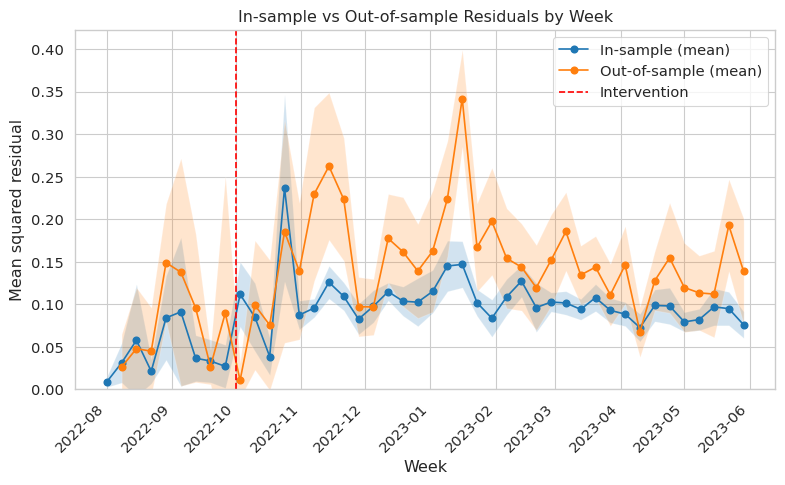

In [107]:
# in sample
in_week = (
    df_in_sample_mf
    .groupby('week_dt')['squared_residual_in_sample']
    .agg(['mean','std','count'])
    .sort_index()
)
in_week['se'] = in_week['std'] / np.sqrt(in_week['count'])
in_week['lo'] = in_week['mean'] - 1.96 * in_week['se']
in_week['hi'] = in_week['mean'] + 1.96 * in_week['se']

# out of sample
oos_week = (
    df_out_of_sample_mf
    .groupby('week_dt')['squared_residual_oos']
    .agg(['mean','std','count'])
    .sort_index()
)
oos_week['se'] = oos_week['std'] / np.sqrt(oos_week['count'])
oos_week['lo'] = oos_week['mean'] - 1.96 * oos_week['se']
oos_week['hi'] = oos_week['mean'] + 1.96 * oos_week['se']

plt.figure(figsize=(8, 5))

plt.plot(in_week.index, in_week['mean'], marker='o', linestyle='-', label='In-sample (mean)')
plt.fill_between(in_week.index, in_week['lo'], in_week['hi'], alpha=0.2)

plt.plot(oos_week.index, oos_week['mean'], marker='o', linestyle='-', label='Out-of-sample (mean)')
plt.fill_between(oos_week.index, oos_week['lo'], oos_week['hi'], alpha=0.2)

intervention_date = "2022-10-01"
plt.axvline(pd.to_datetime(intervention_date), color="red", linestyle="--", label="Intervention")

plt.xlabel('Week')
plt.ylabel('Mean squared residual')
plt.ylim(0, None)
plt.title('In-sample vs Out-of-sample Residuals by Week')
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("final_code/figures/mf_residuals_by_week_2025.png", dpi=300, bbox_inches="tight")
plt.show()


In [111]:
def avg_mse_pre_post(df, cutoff, months, date_col="week_dt", mse_col="mse"):
    cutoff = pd.to_datetime(cutoff)
    d = df.copy()
    d[date_col] = pd.to_datetime(d[date_col])

    pre  = d[(d[date_col] >= cutoff - pd.DateOffset(months=months)) & (d[date_col] < cutoff)][mse_col].dropna()
    post = d[(d[date_col] >= cutoff) & (d[date_col] < cutoff + pd.DateOffset(months=months))][mse_col].dropna()

    pre_mean, post_mean = pre.mean(), post.mean()
    pre_se  = pre.std(ddof=1) / np.sqrt(len(pre))
    post_se = post.std(ddof=1) / np.sqrt(len(post))

    pre_ci  = (pre_mean  - 1.96*pre_se,  pre_mean  + 1.96*pre_se)
    post_ci = (post_mean - 1.96*post_se, post_mean + 1.96*post_se)

    return pre_mean, pre_ci, post_mean, post_ci


In [115]:
pre_mean, pre_ci, post_mean, post_ci = avg_mse_pre_post(
    df_in_sample_mf, "2022-10-01", 3,
    mse_col="squared_residual_in_sample"
)


In [116]:
print(pre_mean, pre_ci, post_mean, post_ci)

0.048752172599057696 (np.float64(0.03266704287024469), np.float64(0.0648373023278707)) 0.10568706896191987 (np.float64(0.10052730874661477), np.float64(0.11084682917722498))


In [117]:
pre_mean_oos, pre_ci_oos, post_mean_oos, post_ci_oos = avg_mse_pre_post(
    df_out_of_sample_mf, "2022-10-01", 3,
    mse_col="squared_residual_oos"
)


In [118]:
print(pre_mean_oos, pre_ci_oos, post_mean_oos, post_ci_oos)

0.09270713817283788 (np.float64(0.060041049054931114), np.float64(0.12537322729074463)) 0.16341599370289214 (np.float64(0.14286801861938872), np.float64(0.18396396878639557))
